# Математическая статистика. Лабораторная работа № 1. Вариант 18
## Угляниц Наталия


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.autolayout": True})
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", None)
def table(frame, digits=4):
    def fmt(value):
        if isinstance(value, (float, np.floating)):
            if np.isinf(value):
                return "+∞" if value > 0 else "−∞"
            return f"{value:.{digits}f}"
        return str(value)
    styled = frame.style.format(fmt).set_properties(**{"white-space": "normal"})
    if isinstance(frame.index, pd.RangeIndex):
        styled = styled.hide(axis="index")
    display(styled)

def interval_text(ci, domain_lower=None, domain_upper=None):
    left = "(" if domain_lower is not None and ci[0] <= domain_lower else "["
    right = ")" if np.isinf(ci[1]) or (domain_upper is not None and ci[1] >= domain_upper) else "]"
    # Не округляем внутреннюю вероятностную границу до 0 или 1.
    digits = 8 if any(0 < value < 1 and round(value, 4) in (0, 1) for value in ci) else 4
    upper = "+∞" if np.isinf(ci[1]) else f"{ci[1]:.{digits}f}"
    return f"{left}{ci[0]:.{digits}f}; {upper}{right}"
def note(text):
    display(Markdown(text))


## Исходные данные

Используем выборки A18 и B18 варианта 18. В части A исследуем дискретные наблюдения, в части B — непрерывную величину, значения которой записаны целыми числами. Для статистических выводов предполагаем независимость наблюдений и одинаковое распределение внутри каждой выборки.

In [2]:
import numpy as np

A = np.array([
    5, 3, 3, 3, 5, 4, 5, 3, 3, 4, 2, 1, 5, 2, 4, 0, 2, 2, 3, 2,
    1, 3, 3, 1, 2, 4, 6, 6, 4, 1, 2, 4, 3, 1, 5, 2, 4, 6, 3, 8,
    4, 5, 1, 1, 2, 0, 2, 3, 3, 2, 4, 2, 1, 2, 3, 1, 2, 4, 3, 0,
    6, 3, 1, 4, 3, 7, 1, 1, 0, 2, 3, 1, 1,
], dtype=int)

B = np.array([
    52, 40, 47, 54, 40, 54, 41, 74, 45, 45, 51, 76, 58, 37, 40,
    42, 53, 54, 65, 46, 65, 61, 55, 38, 66, 42, 56, 54, 40, 60,
    43, 49, 77, 64, 53, 64, 58, 54, 56, 53, 43, 35, 56, 34, 59,
    58, 66, 49, 49, 57, 48, 42, 46, 52, 59, 50, 62, 50, 55, 55,
    46, 53, 51, 50, 60, 30, 48, 56, 29, 74, 52, 60, 44, 62, 23,
    54, 40, 33, 20, 55, 42, 61, 54, 41, 45, 75, 59, 41, 51, 45,
    54, 52, 62, 69, 65, 49, 48, 63, 52, 46, 44, 55, 60, 54, 39,
    82, 67, 68, 34, 56, 51, 56, 48, 53, 47, 59, 51, 59, 66, 48,
    61, 42, 54, 33, 39, 47, 46, 47, 73, 63, 34, 44, 51, 46, 40,
    43, 30, 60, 61, 53, 47, 42, 56, 70, 48, 45, 65, 48, 48, 51,
    40, 57, 56, 33, 44, 43, 45, 35, 35, 56, 59, 66, 56, 52, 44,
    53, 49, 55, 25, 53, 48, 73, 38, 58, 72, 57, 46, 54, 55, 59,
    38, 53, 48, 68, 36, 53, 41, 55, 51, 50, 45, 50, 29, 60, 39,
    50, 59, 33, 56, 49, 31, 70, 56, 56,
], dtype=int)


In [3]:
assert A.size == 73 and B.size == 204
assert A.sum() == 208 and B.sum() == 10437
for name, x in [("A18", A), ("B18", B)]:
    print(f"{name}: n = {len(x)}, сумма = {x.sum()}, минимум = {x.min()}, максимум = {x.max()}")


A18: n = 73, сумма = 208, минимум = 0, максимум = 8
B18: n = 204, сумма = 10437, минимум = 20, максимум = 82


## Часть A
### Размах, статистический ряд и многоугольник распределения
Объём выборки $n=73$, минимум $x_{\min}=0$, максимум $x_{\max}=8$. Размах: $R=x_{\max}-x_{\min}=8$.

Статистический ряд состоит из различных значений $x_i$, абсолютных частот $n_i$ и относительных частот $w_i=n_i/n$.

Проверка: $\sum n_i=n$, $\sum w_i=1$. Многоугольник распределения (полигон) соединяет точки $(x_i,w_i)$.

Обозначения в таблице: $N_i=\sum_{j=1}^{i}n_j$, $W_i=\sum_{j=1}^{i}w_j$ — накопленные абсолютная и относительная частоты.

Минимум = 0, максимум = 8, размах = 8


xᵢ,nᵢ,wᵢ,Nᵢ,Wᵢ
0,4,0.0548,4,0.0548
1,14,0.1918,18,0.2466
2,15,0.2055,33,0.4521
3,17,0.2329,50,0.6849
4,11,0.1507,61,0.8356
5,6,0.0822,67,0.9178
6,4,0.0548,71,0.9726
7,1,0.0137,72,0.9863
8,1,0.0137,73,1.0000


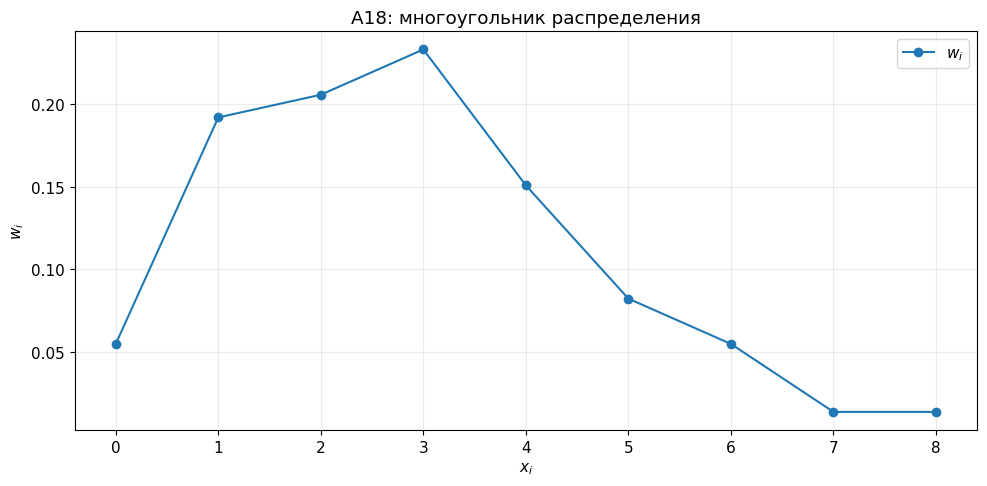

In [4]:
nA = A.size
xA, fA = np.unique(A, return_counts=True)
wA = fA / nA
rowA = pd.DataFrame({"xᵢ": xA, "nᵢ": fA, "wᵢ": wA,
                     "Nᵢ": fA.cumsum(), "Wᵢ": wA.cumsum()})
print(f"Минимум = {A.min()}, максимум = {A.max()}, размах = {np.ptp(A)}")
table(rowA)
assert fA.sum() == nA and np.isclose(wA.sum(), 1)
fig, ax = plt.subplots()
ax.plot(xA, wA, 'o-', label=r"$w_i$")
ax.set(xlabel=r"$x_i$", ylabel=r"$w_i$", xticks=xA,
       title="A18: многоугольник распределения")
ax.legend(); plt.show()


### Эмпирическая функция распределения

$F_n(x)=\frac1n\sum_{j=1}^n\mathbf{1}\{X_j<x\}$: функция непрерывна слева. На $(x_i,x_{i+1}]$ её значение равно накопленной доле наблюдений до $x_i$ включительно. При $x\le x_{\min}$ функция равна 0, при $x>x_{\max}$ — 1.

**Аналитическая запись для A18:**

$$F_{73}(x)=\begin{cases}
0, & x\le0, \\
\frac{4}{73}, & 0<x\le1, \\
\frac{18}{73}, & 1<x\le2, \\
\frac{33}{73}, & 2<x\le3, \\
\frac{50}{73}, & 3<x\le4, \\
\frac{61}{73}, & 4<x\le5, \\
\frac{67}{73}, & 5<x\le6, \\
\frac{71}{73}, & 6<x\le7, \\
\frac{72}{73}, & 7<x\le8, \\
1, & x>8.
\end{cases}$$


Область x,Fₙ(x)
x ≤ 0,0
0 < x ≤ 1,4/73 = 0.0548
1 < x ≤ 2,18/73 = 0.2466
2 < x ≤ 3,33/73 = 0.4521
3 < x ≤ 4,50/73 = 0.6849
4 < x ≤ 5,61/73 = 0.8356
5 < x ≤ 6,67/73 = 0.9178
6 < x ≤ 7,71/73 = 0.9726
7 < x ≤ 8,72/73 = 0.9863
x > 8,73/73 = 1.0000


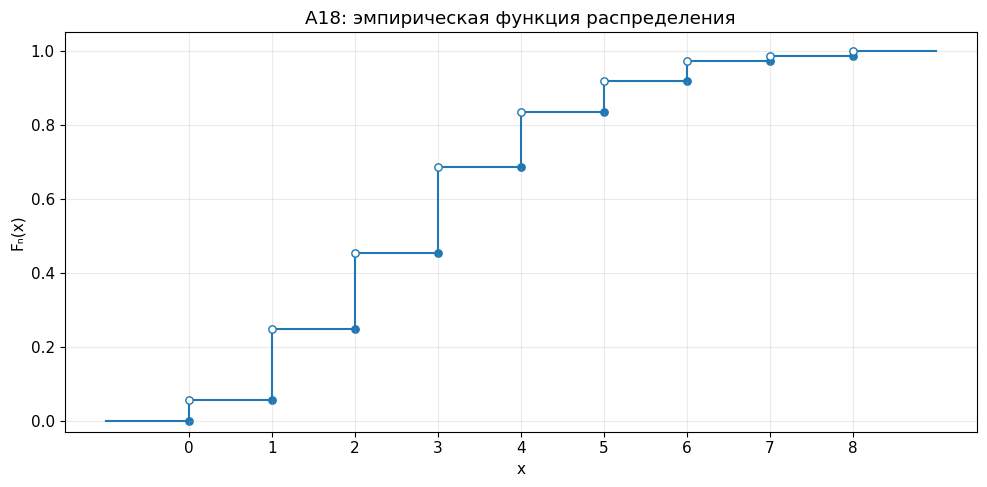

In [5]:
piecesA = [{"Область x": f"x ≤ {xA[0]}", "Fₙ(x)": "0"}]
for i, value in enumerate(xA):
    region = f"{value} < x ≤ {xA[i+1]}" if i + 1 < len(xA) else f"x > {value}"
    piecesA.append({"Область x": region, "Fₙ(x)": f"{fA.cumsum()[i]}/{nA} = {wA.cumsum()[i]:.4f}"})
table(pd.DataFrame(piecesA))
fig, ax = plt.subplots()
ax.step(np.r_[xA[0]-1, xA, xA[-1]+1], np.r_[0, 0, wA.cumsum()], where='pre')
ax.scatter(xA, np.r_[0, wA.cumsum()[:-1]], s=28)
ax.scatter(xA, wA.cumsum(), s=28, facecolors='white', edgecolors='C0', zorder=3)
ax.set(xlabel="x", ylabel="Fₙ(x)", title="A18: эмпирическая функция распределения", ylim=(-.03, 1.05), xticks=xA)
plt.show()


### Теорема Гливенко — Кантелли и смысл эмпирической функции

Пусть $X_1,X_2,\ldots$ — независимые одинаково распределённые наблюдения. Поскольку эмпирическая функция определена через строгое неравенство, теоретическую функцию также запишем в непрерывном слева виде:
$$F_{<}(x)=P(X<x),\qquad F_n(x)=\frac1n\sum_{j=1}^n\mathbf{1}\{X_j<x\}.$$
Тогда теорема Гливенко — Кантелли утверждает:
$$\sup_{x\in\mathbb R}|F_n(x)-F_{<}(x)|\xrightarrow[n\to\infty]{\text{почти наверное}}0.$$

При увеличении объёма выборки эмпирическая функция приближается к теоретической **равномерно по всем $x$** с вероятностью 1.

### Характеристики положения, рассеяния и моменты

$$\bar x=\frac1n\sum x_j,\quad D_n=\frac1n\sum(x_j-\bar x)^2 = \sigma_n^2.$$
$$\alpha_k=\frac1n\sum x_j^k,\quad m_k=\frac1n\sum(x_j-\bar x)^k,\quad As=\frac{m_3}{\sigma_n^3},\quad Es=\frac{m_4}{\sigma_n^4}-3.$$

Мода — наиболее частое значение; медиана вычисляется по упорядоченным наблюдениям. Коэффициент вариации $V=\sqrt{D_n}/\bar x\cdot100\%$. Для асимметрии и эксцесса используем непосредственно эмпирические моменты без поправок на смещение.

Вычисляем **все начальные и центральные моменты от 1-го до 4-го порядка**. В частности, $\alpha_1=\bar x$, $\alpha_2=D_n+\bar x^2$, $m_1=0$, $m_2=D_n$.

#### Центральные моменты через начальные

Первый начальный момент — выборочное среднее: $\alpha_1=\bar x$. Раскрывая степень $(x_j-\alpha_1)^r$ и усредняя, получаем:

$$m_1=\alpha_1-\alpha_1=0,$$
$$m_2=\alpha_2-\alpha_1^2=\sigma_n^2=D_n,$$
$$m_3=\alpha_3-3\alpha_1\alpha_2+2\alpha_1^3,$$
$$m_4=\alpha_4-4\alpha_1\alpha_3+6\alpha_1^2\alpha_2-3\alpha_1^4.$$


In [6]:
def characteristics(x):
    x = np.asarray(x, dtype=float)
    mean = x.mean(); d = x.var(); centered = x - mean
    values, counts = np.unique(x, return_counts=True)
    modes = values[counts == counts.max()]
    return {"n": len(x), "Среднее": mean, "Медиана": np.median(x),
            "Моды": ", ".join(f"{v:g}" for v in modes), "Dₙ": d,
            "σₙ": np.sqrt(d),
            "V, %": 100*np.sqrt(d)/mean,
            "α₃": np.mean(x**3), "α₄": np.mean(x**4),
            "m₃": np.mean(centered**3), "m₄": np.mean(centered**4),
            "Асимметрия As": np.mean(centered**3)/np.sqrt(d)**3,
            "Эксцесс Es": np.mean(centered**4)/np.sqrt(d)**4 - 3}
def show_characteristics(x):
    c = characteristics(x)
    table(pd.DataFrame({"Характеристика": c.keys(), "Значение":
                          [f"{v:.6f}" if isinstance(v, (float, np.floating)) else str(v) for v in c.values()]}))
    return c
cA = show_characteristics(A)
note(f"**Вывод.** Среднее {cA['Среднее']:.4f}, медиана {cA['Медиана']:g} и мода "
     f"{cA['Моды']} находятся около 3. Дисперсия равна {cA['Dₙ']:.4f}, "
     f"стандартное отклонение — {cA['σₙ']:.4f}. Положительная асимметрия "
     f"{cA['Асимметрия As']:.4f} указывает на правый хвост, эксцесс равен {cA['Эксцесс Es']:.4f}. "
     "Выборка принимает неотрицательные целые значения, а дисперсия близка к среднему — "
     "это подводит к гипотезе о распределении Пуассона. В качестве второй дискретной "
     "гипотезы рассмотрим отрицательное биномиальное распределение: оно допускает "
     "ненулевую моду и дисперсию выше среднего. Небольшое превышение дисперсии "
     "над средним мотивирует эту альтернативу, но может быть выборочным колебанием.")


Характеристика,Значение
n,73
Среднее,2.849315
Медиана,3.000000
Моды,3
Dₙ,2.977294
σₙ,1.725484
"V, %",60.557842
α₃,51.589041
α₄,272.301370
m₃,3.006856


**Вывод.** Среднее 2.8493, медиана 3 и мода 3 находятся около 3. Дисперсия равна 2.9773, стандартное отклонение — 1.7255. Положительная асимметрия 0.5853 указывает на правый хвост, эксцесс равен 0.0562. Выборка принимает неотрицательные целые значения, а дисперсия близка к среднему — это подводит к гипотезе о распределении Пуассона. В качестве второй дискретной гипотезы рассмотрим отрицательное биномиальное распределение: оно допускает ненулевую моду и дисперсию выше среднего. Небольшое превышение дисперсии над средним мотивирует эту альтернативу, но может быть выборочным колебанием.

In [7]:
momentsA = pd.DataFrame({
    "Порядок r": np.arange(1, 5),
    "Начальный момент αᵣ": [np.mean(A.astype(float)**r) for r in range(1, 5)],
    "Центральный момент mᵣ": [np.mean((A-A.mean())**r) for r in range(1, 5)]})
# Центральный момент 1-го порядка равен нулю аналитически.
momentsA.loc[0, "Центральный момент mᵣ"] = 0.0
table(momentsA, digits=6)
assert np.isclose(momentsA.loc[1, "Начальный момент αᵣ"], A.var()+A.mean()**2)
note("**Смысл моментов.** Первый начальный момент задаёт центр распределения, "
     "второй центральный — разброс. Третий центральный характеризует асимметрию, "
     "четвёртый — вес больших отклонений от среднего. Их стандартизованные значения "
     "используются для сравнения формы распределений.")


Порядок r,Начальный момент αᵣ,Центральный момент mᵣ
1,2.849315,0.000000
2,11.095890,2.977294
3,51.589041,3.006856
4,272.301370,27.091154


**Смысл моментов.** Первый начальный момент задаёт центр распределения, второй центральный — разброс. Третий центральный характеризует асимметрию, четвёртый — вес больших отклонений от среднего. Их стандартизованные значения используются для сравнения формы распределений.

### Выбор гипотез и точечные оценки

#### Обоснование двух гипотез

Выборка A состоит из неотрицательных целых значений, включая ноль. Поэтому рассматриваем **дискретные распределения с поддержкой $\{0,1,2,\ldots\}$**. Полагаем, что наблюдения независимы и имеют один закон распределения. По данным $n=73$, $\sum x_j=208$, $\bar x=208/73\approx2.8493$, $m_2=\sigma_n^2\approx2.9773$, мода равна 3.

**Гипотеза 1: генеральная совокупность имеет распределение Пуассона** с неизвестным параметром $\lambda>0$:
$$X\sim\operatorname{Pois}(\lambda),\qquad P(X=k)=e^{-\lambda}\frac{\lambda^k}{k!},\quad k=0,1,\ldots.$$

Параметр $\lambda$ задаёт среднее число событий: $M(X)=\lambda$, $\sigma^2=\lambda$. Такой закон часто описывает число событий за фиксированный промежуток при соответствующих предположениях о процессе. Основной аргумент по данным — близость дисперсии к среднему и положительная асимметрия. Для нецелого $\lambda$ мода равна $\lfloor\lambda\rfloor$; небольшое отличие теоретической моды от выборочной допустимо при конечном объёме данных.

**Гипотеза 2: отрицательное биномиальное распределение** с параметрами $r>0$, $0<p<1$:
$$P(X=k)=\frac{\Gamma(k+r)}{\Gamma(r)\,k!}p^r(1-p)^k,\qquad k=0,1,\ldots.$$
$$M(X)=r\frac{1-p}{p},\quad\sigma^2=r\frac{1-p}{p^2}>M(X).$$
При целочисленном $r$ это число неудач до $r$ успехов; допускаем также любое вещественное $r>0$, что задаёт стандартное обобщение модели. Она допускает нули, правый хвост и ненулевую моду. В A дисперсия $2.9773$ немного выше среднего $2.8493$. При большой $r$ и фиксированном среднем отрицательное биномиальное распределение приближается к Пуассону. Небольшое превышение дисперсии над средним может быть выборочным колебанием — оно не доказывает необходимость второго параметра.

#### Методы оценивания

**Метод моментов (ММ):** выражаем теоретические начальные моменты через неизвестные параметры и приравниваем их к соответствующим выборочным моментам $\alpha_r$. Для Пуассона достаточно первого момента; для отрицательного биномиального закона нужны два момента. Полученное уравнение решаем относительно параметра. Приравнивание одного момента не требует совпадения всех остальных моментов.

**Метод максимального правдоподобия (ММП):** при фиксированных наблюдениях выбираем параметр, при котором вероятность получить именно эту выборку максимальна. Для независимых дискретных наблюдений
$$L(\theta)=\prod_{j=1}^{n}P_\theta(X=x_j).$$
Для удобства максимизируем $\ell(\theta)=\ln L(\theta)$: логарифм строго возрастает, поэтому положение максимума сохраняется, а произведение превращается в сумму. Находим стационарную точку и проверяем, что она является максимумом в допустимой области параметра.

#### 1. Распределение Пуассона: метод моментов

Теоретический первый начальный момент $\alpha_1^{\rm theor}=M(X)=\lambda$. Приравниваем его выборочному:
$$\lambda=\alpha_1=\bar x.$$
Следовательно,
$$\boxed{\hat\lambda_{\rm MM}=\bar x=\frac{208}{73}\approx2.849315.}$$
Это уравнение определяет **оценку** неизвестного $\lambda$.

#### 2. Распределение Пуассона: ММП

$$L(\lambda)=\prod_{j=1}^{n}\left(e^{-\lambda}\frac{\lambda^{x_j}}{x_j!}\right)
=e^{-n\lambda}\frac{\lambda^{\sum x_j}}{\prod x_j!}.$$
$$\ell(\lambda)=-n\lambda+\left(\sum x_j\right)\ln\lambda-\sum\ln(x_j!).$$
Последнее слагаемое не зависит от $\lambda$. Дифференцируем:
$$\ell'(\lambda)=-n+\frac{\sum x_j}{\lambda}=0
\quad\Longrightarrow\quad\hat\lambda_{\rm ML}=\frac{\sum x_j}{n}.$$
Поскольку $\sum x_j=208>0$,
$$\ell''(\lambda)=-\frac{\sum x_j}{\lambda^2}<0\qquad(\lambda>0).$$
Логарифм правдоподобия строго вогнут; найденная точка — единственный максимум:
$$\boxed{\hat\lambda_{\rm ML}=\frac{208}{73}\approx2.849315.}$$

#### 3. Отрицательное биномиальное распределение: метод моментов

Обозначим $u=\alpha_1=\bar x$, $v=m_2=\alpha_2-\alpha_1^2$. Приравниваем теоретические среднее и дисперсию выборочным:
$$u=r\frac{1-p}{p},\qquad v=r\frac{1-p}{p^2}.$$
Деление первого уравнения на второе даёт $p=u/v$. Подставляя обратно:
$$\boxed{\hat p_{\rm MM}=\frac uv,\qquad\hat r_{\rm MM}=\frac{u^2}{v-u}.}$$
Решение допустимо при $v>u>0$, что выполнено в A. При $v\approx u$ оценка $r$ чувствительна к небольшой разности $v-u$.

#### 4. Отрицательное биномиальное распределение: ММП

Для независимой выборки
$$\ell(r,p)=\sum_j[\ln\Gamma(x_j+r)-\ln\Gamma(r)-\ln(x_j!)]
+nr\ln p+\left(\sum_jx_j\right)\ln(1-p).$$
При фиксированном $r$:
$$\frac{\partial\ell}{\partial p}=\frac{nr}{p}-\frac{\sum x_j}{1-p}=0
\quad\Longrightarrow\quad\hat p(r)=\frac r{r+\bar x}.$$
Вторая производная по $p$ отрицательна, поэтому это условный максимум. Для $r$ получаем уравнение с дигамма-функцией $\psi(t)=\frac{d}{dt}\ln\Gamma(t)$:
$$\sum_j[\psi(x_j+r)-\psi(r)]+n\ln\frac r{r+\bar x}=0.$$
В коде численно максимизируем профиль $\ell(r,\hat p(r))$ и сравниваем его с пуассоновским пределом $r\to\infty$. Оценки ММ и ММП в этой модели не обязаны совпадать. Для последующих частот, моментов и интервалов используем **ММ**, чтобы модель воспроизводила рассчитанные среднее и дисперсию A.


In [8]:
from scipy import optimize
lam = float(A.mean()); varA = float(A.var())
p_nb = lam/varA
r_nb = lam**2/(varA-lam)
assert 0 < p_nb < 1 and r_nb > 0
pois = stats.poisson(lam)
nbinom = stats.nbinom(r_nb,p_nb)
def profile_nb(log_r):
    r = np.exp(log_r); p = r/(r+lam)
    return -float(stats.nbinom.logpmf(A,r,p).sum())
fit_nb = optimize.minimize_scalar(profile_nb,bounds=(-8,14),method='bounded')
assert fit_nb.success
r_ml = float(np.exp(fit_nb.x)); p_ml = r_ml/(r_ml+lam)
ll_pois = float(pois.logpmf(A).sum())
ll_nb = -float(fit_nb.fun)
table(pd.DataFrame({"Модель": ["Пуассон","Отрицательное биномиальное","Отрицательное биномиальное"],
    "Параметр": ["λ","r","p"], "Метод моментов": [lam,r_nb,p_nb],
    "ММП": [lam,r_ml,p_ml]}))

assert -7.9 < fit_nb.x < 13.9
assert ll_nb >= ll_pois - 1e-7
note(f"**Промежуточный вывод.** Для Пуассона оба метода дают λ={lam:.4f}. "
     f"Для отрицательного биномиального закона ММ даёт r={r_nb:.4f}, p={p_nb:.4f}, "
     f"ММП — r={r_ml:.4f}, p={p_ml:.4f}. Логарифм правдоподобия в максимуме NB "
     f"равен {ll_nb:.4f}, в пуассоновском пределе — {ll_pois:.4f}. "
     "Небольшой выигрыш при дополнительном параметре сам по себе не определяет выбор модели.")


Модель,Параметр,Метод моментов,ММП
Пуассон,λ,2.8493,2.8493
Отрицательное биномиальное,r,63.4370,62.3859
Отрицательное биномиальное,p,0.9570,0.9563


**Промежуточный вывод.** Для Пуассона оба метода дают λ=2.8493. Для отрицательного биномиального закона ММ даёт r=63.4370, p=0.9570, ММП — r=62.3859, p=0.9563. Логарифм правдоподобия в максимуме NB равен -140.1589, в пуассоновском пределе — -140.1951. Небольшой выигрыш при дополнительном параметре сам по себе не определяет выбор модели.

### Теоретические вероятности, частоты и полигоны

Подставляем оценки ММ в формулы распределений:
$$p_k^{\rm Pois}=e^{-\hat\lambda}\frac{\hat\lambda^k}{k!},\qquad
p_k^{\rm NB}=\frac{\Gamma(k+\hat r)}{\Gamma(\hat r)k!}\hat p^{\hat r}(1-\hat p)^k.$$
Теоретическая частота равна $np_k$. Сравниваем её с наблюдаемой частотой $n_k$, а вероятность $p_k$ — с относительной частотой $w_k$. Значения $k\ge9$ объединяем в последнюю строку таблицы.


k,Эмпирическая частота,P Пуассон,nP Пуассон,P отрицательная биномиальная,nP отрицательная биномиальная
0,4,0.0579,4.2255,0.0616,4.4964
1,14,0.1649,12.0399,0.1680,12.2610
2,15,0.2350,17.1527,0.2326,16.9804
3,17,0.2232,16.2911,0.2181,15.9208
4,11,0.1590,11.6046,0.1557,11.3667
5,6,0.0906,6.6131,0.0903,6.5899
6,4,0.0430,3.1404,0.0443,3.2310
7,1,0.0175,1.2783,0.0189,1.3777
8,1,0.0062,0.4553,0.0071,0.5214
≥ 9,0,0.0027,0.1991,0.0035,0.2548


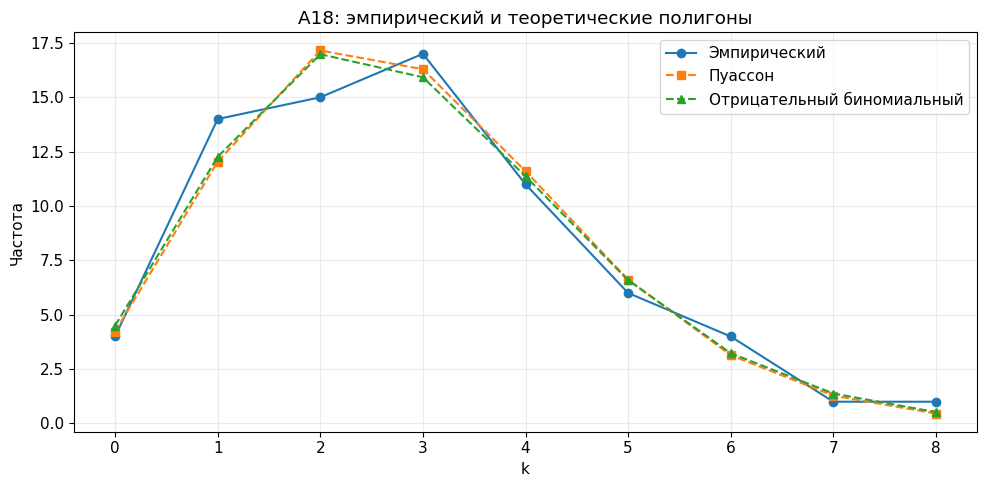

**Вывод.** Теоретические полигоны близки. У обеих моделей мода равна 2, у выборки — 3. Отрицательное биномиальное распределение воспроизводит выборочную дисперсию по методу моментов; у Пуассона она немного меньше.

In [9]:
freqA = pd.DataFrame({"k": xA, "Эмпирическая частота": fA,
                      "P Пуассон": pois.pmf(xA), "nP Пуассон": nA*pois.pmf(xA),
                      "P отрицательная биномиальная": nbinom.pmf(xA), "nP отрицательная биномиальная": nA*nbinom.pmf(xA)})
tailA = pd.DataFrame({"k": ["≥ 9"], "Эмпирическая частота": [0],
                     "P Пуассон": [pois.sf(8)], "nP Пуассон": [nA*pois.sf(8)],
                     "P отрицательная биномиальная": [nbinom.sf(8)], "nP отрицательная биномиальная": [nA*nbinom.sf(8)]})
table(pd.concat([freqA, tailA], ignore_index=True))
assert np.isclose(pois.pmf(xA).sum()+pois.sf(8), 1)
assert np.isclose(nbinom.pmf(xA).sum()+nbinom.sf(8), 1)
fig, ax = plt.subplots()
ax.plot(xA, fA, 'o-', label="Эмпирический")
ax.plot(xA, nA*pois.pmf(xA), 's--', label="Пуассон")
ax.plot(xA, nA*nbinom.pmf(xA), '^--', label="Отрицательный биномиальный")
ax.set(xlabel="k", ylabel="Частота", title="A18: эмпирический и теоретические полигоны", xticks=xA)
ax.legend(); plt.show()
note("**Вывод.** Теоретические полигоны близки. У обеих моделей мода равна 2, "
     "у выборки — 3. Отрицательное биномиальное распределение воспроизводит "
     "выборочную дисперсию по методу моментов; у Пуассона она немного меньше.")


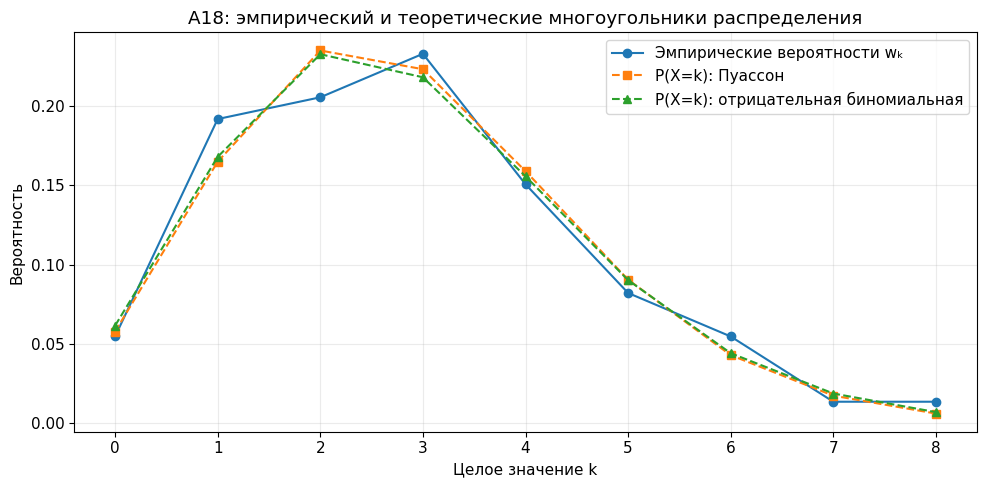

In [10]:
fig, ax = plt.subplots()
ax.plot(xA, wA, 'o-', label="Эмпирические вероятности wₖ")
ax.plot(xA, pois.pmf(xA), 's--', label="P(X=k): Пуассон")
ax.plot(xA, nbinom.pmf(xA), '^--', label="P(X=k): отрицательная биномиальная")
ax.set(xlabel="Целое значение k", ylabel="Вероятность", xticks=xA,
       title="A18: эмпирический и теоретические многоугольники распределения")
ax.legend(); plt.show()


### Доверительные интервалы для параметров A

Доверительный уровень $\gamma=0.95$, $z_{0.975}\approx1.96$. Интервалы асимптотические; $SE$ обозначает стандартную ошибку оценки. Сравним прямой способ и функциональное преобразование.

#### 1. Распределение Пуассона

При $\hat\lambda=\bar x$ стандартная ошибка равна $SE_\lambda=\sqrt{\hat\lambda/n}$.

**Прямой интервал:**
$$I_\lambda=\left[\hat\lambda-z\sqrt{\frac{\hat\lambda}{n}};\quad
\hat\lambda+z\sqrt{\frac{\hat\lambda}{n}}\right].$$

**Преобразование $g(\lambda)=2\sqrt\lambda$:**
$$I_\lambda^{(g)}=\left[
\left(\sqrt{\hat\lambda}-\frac{z}{2\sqrt n}\right)^2;\quad
\left(\sqrt{\hat\lambda}+\frac{z}{2\sqrt n}\right)^2\right].$$
В нашей выборке нижняя граница в шкале корня положительна.


In [11]:
z = float(stats.norm.ppf(.975))
se_lam = np.sqrt(lam/nA)
ci_lam = lam + np.array([-1, 1])*z*se_lam
ci_lam_transform = np.array([
    max(0, np.sqrt(lam)-z/(2*np.sqrt(nA)))**2,
    (np.sqrt(lam)+z/(2*np.sqrt(nA)))**2])
note(f"Оценка λ̂={lam:.4f}; стандартная ошибка {se_lam:.4f}.")
table(pd.DataFrame({"Способ": ["Прямой", "Преобразование 2√λ"],
                    "95% интервал для λ": [interval_text(ci_lam), interval_text(ci_lam_transform)]}))
note("**Вывод.** Оба способа дают близкие границы интервала для λ.")


Оценка λ̂=2.8493; стандартная ошибка 0.1976.

Способ,95% интервал для λ
Прямой,[2.4621; 3.2365]
Преобразование 2√λ,[2.4753; 3.2497]


**Вывод.** Оба способа дают близкие границы интервала для λ.

#### 2. Отрицательное биномиальное распределение

Оценки ММ: $\hat p=\bar x/m_2$, $\hat r=\bar x^2/(m_2-\bar x)$. Стандартные ошибки рассчитываем дельта-методом с учётом совместного разброса среднего и дисперсии; расчёт приведён в коде.

**Прямые интервалы:**
$$I_p=[\hat p-zSE_p;\hat p+zSE_p]\cap(0;1),\qquad
I_r=[\hat r-zSE_r;\hat r+zSE_r]\cap(0;+\infty).$$

**Преобразование для $p$.** Положим
$$\eta=\ln\frac{\hat p}{1-\hat p},\qquad SE_\eta=\frac{SE_p}{\hat p(1-\hat p)}.$$
Границы $\eta\pm zSE_\eta$ переводим обратно функцией $1/(1+e^{-t})$.

**Преобразование для $r$.** Для $\delta=1/r$ строим $[L;U]=[\hat\delta-zSE_\delta;\hat\delta+zSE_\delta]$. Тогда
$$I_r^{(g)}=\begin{cases}[1/U;1/L],&L>0,\\{}[1/U;+\infty),&L\le0<U.\end{cases}$$
Открытые границы 0 и 1 исключены из области параметров. Основным для $r$ считаем преобразованный интервал.


In [12]:
from scipy.special import expit
u, v = lam, varA
delta_nb = 1/r_nb
cov_uv = np.array([[v, cA['m₃']], [cA['m₃'], cA['m₄']-v**2]])/nA
J_nb = np.array([[1/v, -u/v**2], [-1/u**2-2*(v-u)/u**3, 1/u**2]])
se_nb = np.sqrt(np.diag(J_nb @ cov_uv @ J_nb.T))
se_r = r_nb**2*se_nb[1]
ci_p = np.clip(p_nb + np.array([-1, 1])*z*se_nb[0], 0, 1)
ci_r_wald = np.maximum(0, r_nb + np.array([-1, 1])*z*se_r)
ci_delta = delta_nb + np.array([-1, 1])*z*se_nb[1]
assert ci_delta[1] > 0
ci_r = np.array([1/ci_delta[1], np.inf if ci_delta[0] <= 0 else 1/ci_delta[0]])
logit_p = np.log(p_nb/(1-p_nb))
ci_p_transform = expit(logit_p + np.array([-1, 1])*z*se_nb[0]/(p_nb*(1-p_nb)))
table(pd.DataFrame({"Параметр": ["p", "r", "δ=1/r"],
                    "Оценка": [p_nb, r_nb, delta_nb],
                    "Стандартная ошибка": [se_nb[0], se_r, se_nb[1]]}))
table(pd.DataFrame({"Параметр": ["p", "r"],
                    "Прямой 95% интервал": [interval_text(ci_p, 0, 1), interval_text(ci_r_wald, 0)],
                    "Преобразованный 95% интервал": [interval_text(ci_p_transform), interval_text(ci_r)]}))
note(f"**Вывод.** Интервал для δ равен {interval_text(ci_delta)} и содержит 0, "
     f"поэтому для r получаем {interval_text(ci_r)}. Параметр r определён неточно; "
     "пуассоновский предел не исключён. Интервалы для p заметно зависят от способа расчёта.")


Параметр,Оценка,Стандартная ошибка
p,0.9570,0.1466
r,63.4370,226.2533
δ=1/r,0.0158,0.0562


Параметр,Прямой 95% интервал,Преобразованный 95% интервал
p,[0.6696; 1.0000),[0.02015622; 0.99995850]
r,(0.0000; 506.8853],[7.9392; +∞)


**Вывод.** Интервал для δ равен [-0.0944; 0.1260] и содержит 0, поэтому для r получаем [7.9392; +∞). Параметр r определён неточно; пуассоновский предел не исключён. Интервалы для p заметно зависят от способа расчёта.

### Теоретические характеристики и сравнение

Пуассон: $M(X)=\sigma^2=\lambda$, $As=1/\sqrt\lambda$, $Es=1/\lambda$, мода $\lfloor\lambda\rfloor$ (при целой положительной $\lambda$ также $\lambda-1$).

Отрицательное биномиальное распределение:
$$M(X)=\frac{r(1-p)}p,\quad\sigma^2=\frac{r(1-p)}{p^2},\quad
As=\frac{2-p}{\sqrt{r(1-p)}},\quad Es=\frac6r+\frac{p^2}{r(1-p)}.$$
При $r>1$ мода $\lfloor(r-1)(1-p)/p\rfloor$; если выражение целое, возможна также предыдущая целая мода. Медиану определяем как наименьшее целое с $P(X\le k)\ge0.5$. Далее вычисляем показатели по параметрам ММ.

In [13]:
def distribution_characteristics(rv, mode):
    mean, var, skew, kurt = rv.stats(moments='mvsk')
    return {"Среднее": float(mean), "Медиана": float(rv.ppf(.5)), "Мода": mode,
            "Дисперсия": float(var), "As": float(skew), "Es": float(kurt)}
def empirical_compare(c):
    return {"Среднее": c['Среднее'], "Медиана": c['Медиана'], "Мода": c['Моды'],
            "Дисперсия": c['Dₙ'], "As": c['Асимметрия As'], "Es": c['Эксцесс Es']}
compareA = pd.DataFrame({"Эмпирические": empirical_compare(cA),
                         "Пуассон": distribution_characteristics(pois, int(np.floor(lam))),
                         "Отрицательная биномиальная": distribution_characteristics(nbinom, int(np.floor((r_nb-1)*(1-p_nb)/p_nb)))})
table(compareA)
note("**Вывод.** Среднее совпадает у обеих моделей. Отрицательное биномиальное "
     "распределение также воспроизводит дисперсию, но совпадение заданных моментов "
     "само по себе не подтверждает гипотезу.")


,Эмпирические,Пуассон,Отрицательная биномиальная
Среднее,2.8493,2.8493,2.8493
Медиана,3.0000,3.0000,3.0000
Мода,3,2.0000,2.0000
Дисперсия,2.9773,2.8493,2.9773
As,0.5853,0.5924,0.6316
Es,0.0562,0.3510,0.4305


**Вывод.** Среднее совпадает у обеих моделей. Отрицательное биномиальное распределение также воспроизводит дисперсию, но совпадение заданных моментов само по себе не подтверждает гипотезу.

In [14]:
# Дополнительное сравнение моментов A с теоретическими.
# Для Пуассона m₃=λ, m₄=λ+3λ²; для отрицательного биномиального
# m₃=As·v^(3/2), m₄=(Es+3)·v².
def raw_central_moments(rv):
    mean, var, skew, kurt = map(float, rv.stats(moments='mvsk'))
    m3 = skew*var**1.5; m4 = (kurt+3)*var**2
    return {"α₃": mean**3+3*mean*var+m3,
            "α₄": mean**4+6*mean**2*var+4*mean*m3+m4,
            "m₃": m3, "m₄": m4}
table(pd.DataFrame({"Эмпирические": {k:cA[k] for k in ['α₃','α₄','m₃','m₄']},
                    "Пуассон": raw_central_moments(pois),
                    "Отрицательная биномиальная": raw_central_moments(nbinom)}))


,Эмпирические,Пуассон,Отрицательная биномиальная
α₃,51.5890,50.3375,51.8269
α₄,272.3014,264.3857,278.3301
m₃,3.0069,2.8493,3.2447
m₄,27.0912,27.2051,30.4085


## Часть B
### Выбор числа интервалов и группировка

Рассмотрим три практических правила:

| Правило | Формула | При $n=204$ | Выбранное целое $k$ |
|---|---|---|---|
| $5\lg n$ | $k=5\lg n$ | 11.5482 | 12 |
| Стерджеса | $k=1+3.322\lg n$ | 8.6727 | 9 |
| Квадратного корня | $k=\sqrt n$ | 14.2829 | 14 |

Выбираем правило квадратного корня: $k_0=\operatorname{round}(\sqrt{204})=14$. Исходный размах $R=82-20=62$, расчётная длина интервала:
$$h_0=\frac{R}{k_0}=\frac{62}{14}\approx4.4286.$$
Для удобных границ принимаем **$h=5$**. От минимального значения 20 получаем интервалы $[20;25),[25;30),\ldots,[75;80),[80;85]$.

После округления ширины фактическое число интервалов уточняется: $k=\lceil R/h\rceil=13$. Таким образом, **14 — ориентир по правилу квадратного корня, 13 — фактическое число интервалов шириной 5**. Последний интервал включает максимум 82, его верхняя граница равна 85.

Все интервалы закрыты слева и открыты справа, последний закрыт с обеих сторон. Поэтому наблюдение на внутренней границе, например 25, относится к интервалу $[25;30)$. Высота гистограммы $n_i/(nh)$; её площадь равна 1. Описательные характеристики и оценки параметров B рассчитываем по этому интервальному ряду. Исключение — точные нормальные доверительные интервалы: для них потребуются исходные наблюдения.

Минимум = 20, максимум = 82, R = 62; k = 13, h = 5.000000


Интервал,cᵢ,nᵢ,wᵢ,nᵢ/(nh),Nᵢ,Wᵢ
[20; 25),22.5000,2,0.0098,0.0020,2,0.0098
[25; 30),27.5000,3,0.0147,0.0029,5,0.0245
[30; 35),32.5000,10,0.0490,0.0098,15,0.0735
[35; 40),37.5000,11,0.0539,0.0108,26,0.1275
[40; 45),42.5000,26,0.1275,0.0255,52,0.2549
[45; 50),47.5000,35,0.1716,0.0343,87,0.4265
[50; 55),52.5000,41,0.2010,0.0402,128,0.6275
[55; 60),57.5000,36,0.1765,0.0353,164,0.8039
[60; 65),62.5000,17,0.0833,0.0167,181,0.8873
[65; 70),67.5000,12,0.0588,0.0118,193,0.9461


Ориентир по √n: 14; фактическое число интервалов: 13
Расчётная ширина R/k = 4.428571; выбранная h = 5


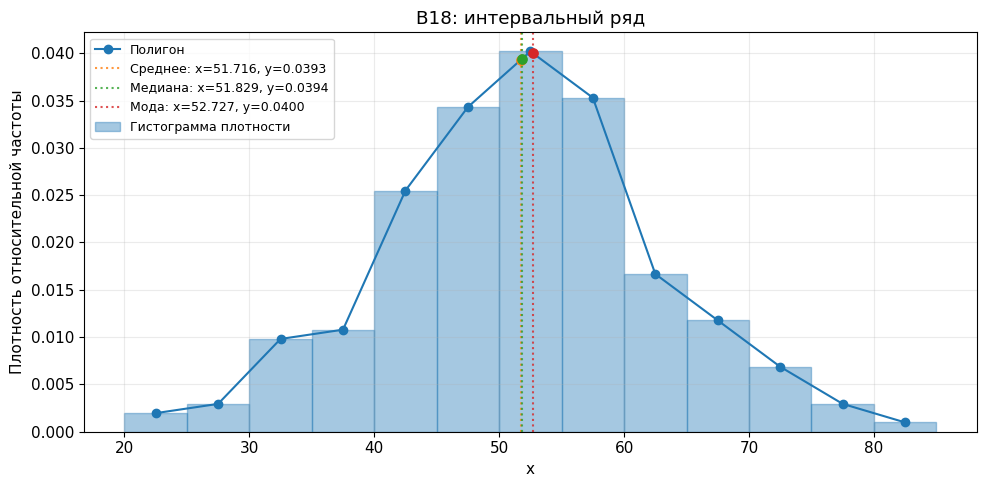

**Вывод по расположению.** среднее (51.716) < медиана (51.829) < мода (52.727). Размах между тремя характеристиками равен 1.012, то есть 0.20 длины интервала. Они расположены в центральной области полигона. Близость среднего и медианы подводит к предположению о примерно симметричном распределении; смещение моды связано с положением наиболее заполненного интервала и зависит от группировки. Одного порядка этих трёх величин недостаточно для вывода об асимметрии — далее учитываем коэффициент As.

In [15]:

def mark_b(ax, kind):
    """Отметки с координатами на полигоне или кумуляте и Fгр."""
    for idx, (value, label, color) in enumerate([(mean_group,"Среднее","C1"),
            (median_group,"Медиана","C2"),(mode_group,"Мода","C3")]):
        if kind in ("polygon", "frequency"):
            heights = densityB if kind == "polygon" else fB
            y = float(np.interp(value, mid, heights))
            legend = f"{label}: x={value:.3f}, y={y:.4f}"
        else:
            y = float(np.interp(value, edges, cum_group))
            # Строгое неравенство обеспечивает непрерывность слева.
            y_step = float(np.sum(wB[edges[:-1] < value]))
            legend = f"{label}: x={value:.3f}, yкум={y:.4f}, yF={y_step:.4f}"
            ax.scatter(value, y_step, color=color, marker='x', zorder=6)
        ax.axvline(value, color=color, linestyle=':', alpha=.8, label=legend)
        ax.scatter(value, y, color=color, s=45, zorder=6)

nB = len(B)
k_rule = int(np.round(np.sqrt(nB)))
h0 = np.ptp(B)/k_rule
h = 5.0
kB = int(np.ceil(np.ptp(B)/h))
edges = B.min()+h*np.arange(kB+1)
fB, _ = np.histogram(B, bins=edges)
mid = (edges[:-1]+edges[1:])/2
wB = fB/nB
densityB = wB/h
interval_labels = [f"[{a:g}; {b:g}{']' if i==kB-1 else ')'}" for i,(a,b) in enumerate(zip(edges[:-1],edges[1:]))]
rowB = pd.DataFrame({"Интервал": interval_labels, "cᵢ": mid, "nᵢ": fB,
                    "wᵢ": wB, "nᵢ/(nh)": densityB, "Nᵢ": fB.cumsum(), "Wᵢ": wB.cumsum()})
print(f"Минимум = {B.min()}, максимум = {B.max()}, R = {np.ptp(B)}; k = {kB}, h = {h:.6f}")
table(rowB)
print(f"Ориентир по √n: {k_rule}; фактическое число интервалов: {kB}")
print(f"Расчётная ширина R/k = {h0:.6f}; выбранная h = {h:g}")
# Интервальные характеристики для отметок уже на графике функции.
mean_group = float(np.dot(mid, wB))
med_idx = int(np.searchsorted(np.cumsum(fB), nB/2))
median_group = edges[med_idx]+h*(nB/2-fB[:med_idx].sum())/fB[med_idx]
mode_idx = int(np.argmax(fB))
fl = fB[mode_idx-1] if mode_idx else 0
fr = fB[mode_idx+1] if mode_idx+1<kB else 0
mode_group = edges[mode_idx]+h*(fB[mode_idx]-fl)/(2*fB[mode_idx]-fl-fr)
assert fB.sum() == nB and np.isclose(np.sum(densityB*h), 1)
fig, ax = plt.subplots()
ax.bar(mid, densityB, width=h, alpha=.4, edgecolor='C0', label="Гистограмма плотности")
ax.plot(mid, densityB, 'o-', label="Полигон")
ax.set(xlabel="x", ylabel="Плотность относительной частоты", title="B18: интервальный ряд")
mark_b(ax, "polygon")
ax.legend(loc='upper left', fontsize=9); plt.show()
ordered = sorted([(mean_group,"среднее"),(median_group,"медиана"),(mode_group,"мода")])
order_text = " < ".join(f"{name} ({value:.3f})" for value,name in ordered)
span = max(mean_group,median_group,mode_group)-min(mean_group,median_group,mode_group)
note(f"**Вывод по расположению.** {order_text}. Размах между тремя характеристиками "
     f"равен {span:.3f}, то есть {span/h:.2f} длины интервала. Они расположены в центральной "
     "области полигона. Близость среднего и медианы подводит к предположению о примерно "
     "симметричном распределении; смещение моды связано с положением наиболее заполненного "
     "интервала и зависит от группировки. Одного порядка этих трёх величин недостаточно "
     "для вывода об асимметрии — далее учитываем коэффициент As.")

assert edges[0] == 20 and edges[-1] == 85 and np.all(np.diff(edges) == 5)


### Эмпирическая функция интервального ряда и кумулята

Пусть $a_0=20,a_1=25,\ldots,a_{13}=85$, $W_i=\sum_{j=1}^{i}n_j/n$, $W_0=0$.

Для сгруппированного ряда принимаем функцию, непрерывную слева:
$$F_{\rm гр}(x)=\begin{cases}0,&x\le a_0,\\W_i,&a_{i-1}<x\le a_i,\quad i=1,\ldots,k,\\1,&x>a_k.\end{cases}$$
Таким образом, на $(20;25]$ стоит $W_1$, на $(25;30]$ — $W_2$ и т.д.

i,aᵢ,Nᵢ,Wᵢ
0,20.0000,0,0.0000
1,25.0000,2,0.0098
2,30.0000,5,0.0245
3,35.0000,15,0.0735
4,40.0000,26,0.1275
5,45.0000,52,0.2549
6,50.0000,87,0.4265
7,55.0000,128,0.6275
8,60.0000,164,0.8039
9,65.0000,181,0.8873


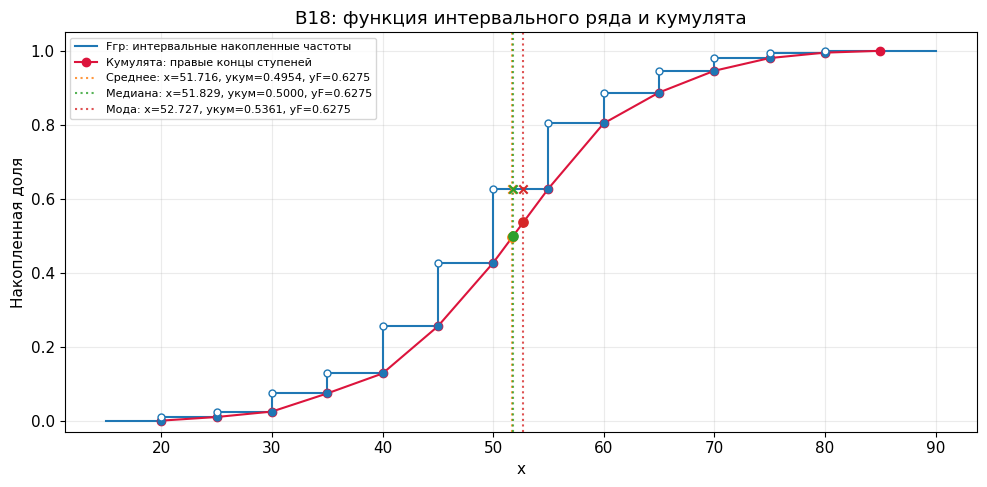

**Уровень 0,5 на кумуляте достигается при x = 51.829268.** Это интервальная медиана: 50 + 5 × (204/2 − 87)/41 = 51.829268.

In [16]:
cum_group = np.r_[0, np.cumsum(wB)]
table(pd.DataFrame({"i": np.arange(kB+1), "aᵢ": edges,
                    "Nᵢ": np.r_[0, fB.cumsum()], "Wᵢ": cum_group}))
fig, ax = plt.subplots()
ax.step(np.r_[edges[0]-h, edges, edges[-1]+h], np.r_[0, cum_group, 1],
        where='pre', label="Fгр: интервальные накопленные частоты")
ax.plot(edges, cum_group, 'o-', color='crimson', label="Кумулята: правые концы ступеней")
ax.scatter(edges[:-1], cum_group[:-1], color='C0', s=25, zorder=4)
ax.scatter(edges[:-1], cum_group[1:], facecolors='white', edgecolors='C0', s=25, zorder=4)
mark_b(ax, "cumulative")
ax.set(xlabel="x", ylabel="Накопленная доля", title="B18: функция интервального ряда и кумулята", ylim=(-.03,1.05))
ax.legend(loc='upper left', fontsize=8); plt.show()

note(f"**Уровень 0,5 на кумуляте достигается при x = {median_group:.6f}.** "
     f"Это интервальная медиана: {edges[med_idx]:g} + {h:g} × "
     f"({nB}/2 − {fB[:med_idx].sum()})/{fB[med_idx]} = {median_group:.6f}.")


### Характеристики по интервальному ряду

Среднее и моменты B рассчитываем по частотам $n_i$ и серединам $c_i=(a_{i-1}+a_i)/2$:
$$\bar x=\frac1n\sum_i n_ic_i,\quad\alpha_r=\frac1n\sum_i n_ic_i^r,\quad m_r=\frac1n\sum_i n_i(c_i-\bar x)^r,\quad r=1,2,3,4.$$
$$\sigma_n^2=m_2=\alpha_2-\alpha_1^2,\quad As=\frac{m_3}{\sigma_n^3},\quad Es=\frac{m_4}{\sigma_n^4}-3.$$

Медианный интервал — первый, в котором накопленная частота достигает $n/2$:
$$Me_X=L_{Me}+h\frac{n/2-N_{\rm пред}}{n_{Me}}.$$
Здесь $L_{Me}$ — нижняя граница медианного интервала; $N_{\rm пред}$ — **накопленная частота всех предыдущих интервалов**, $n_{Me}$ — частота медианного интервала.

Для модального интервала с максимальной частотой $n_m$:
$$Mo_X=L_{Mo}+h\frac{n_m-n_{m-1}}{(n_m-n_{m-1})+(n_m-n_{m+1})}.$$



Характеристика,Значение
n,204
Среднее,51.7157
Медиана,51.8293
Моды,52.727273
Dₙ,119.4829
σₙ,10.9308
"V, %",21.1364
α₃,156856.3113
α₄,9115670.1900
m₃,4.6579


r,αᵣ,mᵣ
1,51.715686,0.000000
2,2793.995098,119.482891
3,156856.311275,4.657899
4,9115670.189951,44340.393489


Медианный интервал: [50; 55), Nпред=87, nMe=41
MeX = 50.000000 + 5.000000 × (204/2 − 87)/41 = 51.829268


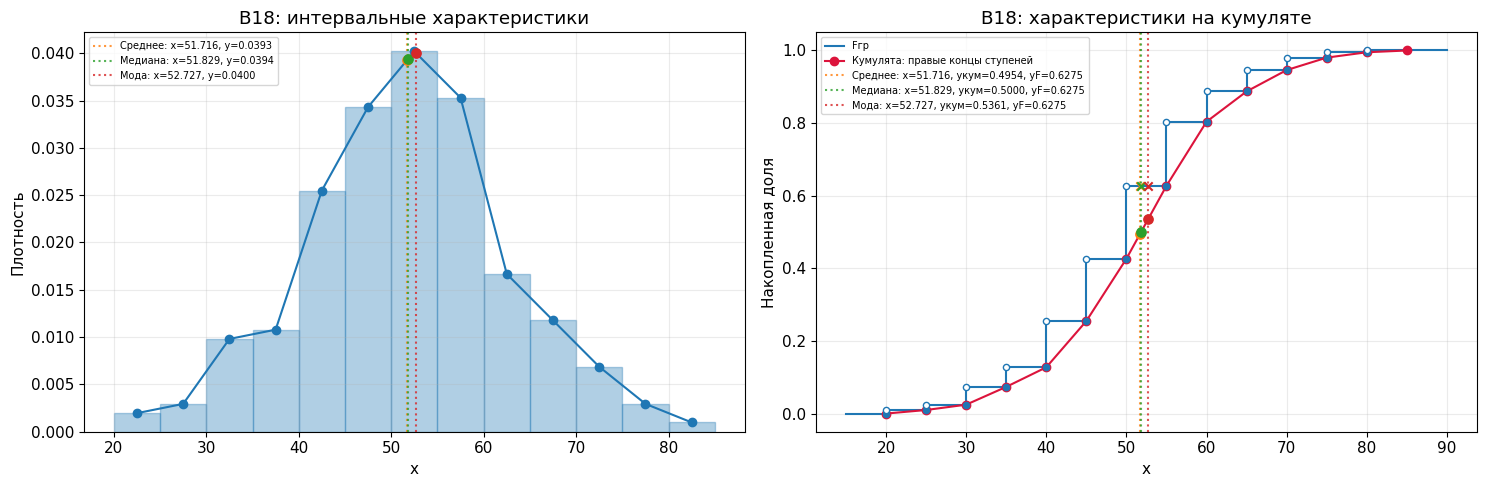

**Вывод.** По интервальному ряду среднее 51.7157, медиана 51.8293, мода 52.7273, стандартное отклонение 10.9308. As=0.0036, Es=0.1059. Близость асимметрии и эксцесса к нулю подводит к нормальной гипотезе. В качестве альтернативы рассмотрим распределение Стьюдента с параметрами положения и масштаба: оно симметрично, но допускает более тяжёлые хвосты и положительный эксцесс. 

In [17]:
mean_group = float(np.dot(mid, wB))
med_idx = int(np.searchsorted(np.cumsum(fB), nB/2))
prev = fB[:med_idx].sum()
median_group = edges[med_idx]+h*(nB/2-prev)/fB[med_idx]
mode_idx = int(np.argmax(fB))
left_freq = fB[mode_idx-1] if mode_idx else 0
right_freq = fB[mode_idx+1] if mode_idx+1<kB else 0
mode_group = edges[mode_idx]+h*(fB[mode_idx]-left_freq)/(2*fB[mode_idx]-left_freq-right_freq)
rawB = np.array([np.dot(wB, mid**r) for r in range(1,5)])
centralB = np.array([np.dot(wB, (mid-mean_group)**r) for r in range(1,5)])
centralB[0] = 0.0
dB = centralB[1]; sdB = np.sqrt(dB)
cB = {"n": nB, "Среднее": mean_group, "Медиана": median_group, "Моды": f"{mode_group:.6f}",
      "Dₙ": dB, "σₙ": sdB, "V, %": 100*sdB/mean_group,
      "α₃": rawB[2], "α₄": rawB[3], "m₃": centralB[2], "m₄": centralB[3],
      "Асимметрия As": centralB[2]/sdB**3, "Эксцесс Es": centralB[3]/sdB**4-3}
table(pd.DataFrame({"Характеристика": list(cB), "Значение": list(cB.values())}))
table(pd.DataFrame({"r": np.arange(1,5), "αᵣ": rawB, "mᵣ": centralB}), digits=6)
print(f"Медианный интервал: {interval_labels[med_idx]}, Nпред={prev}, nMe={fB[med_idx]}")
print(f"MeX = {edges[med_idx]:.6f} + {h:.6f} × ({nB}/2 − {prev})/{fB[med_idx]} = {median_group:.6f}")
fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].bar(mid,densityB,width=h,alpha=.35,edgecolor='C0')
axes[0].plot(mid,densityB,'o-')
axes[1].step(np.r_[edges[0]-h,edges,edges[-1]+h],np.r_[0,cum_group,1],where='pre',label="Fгр")
axes[1].scatter(edges[:-1],cum_group[:-1],color='C0',s=20,zorder=4)
axes[1].scatter(edges[:-1],cum_group[1:],facecolors='white',edgecolors='C0',s=20,zorder=4)
axes[1].plot(edges,cum_group,'o-',color='crimson',label="Кумулята: правые концы ступеней")
mark_b(axes[0], "polygon")
mark_b(axes[1], "cumulative")
for ax in axes:
    ax.set_xlabel("x"); ax.legend(loc='upper left', fontsize=7)
axes[0].set(title="B18: интервальные характеристики",ylabel="Плотность")
axes[1].set(title="B18: характеристики на кумуляте",ylabel="Накопленная доля")
plt.tight_layout(); plt.show()
note(f"**Вывод.** По интервальному ряду среднее {mean_group:.4f}, медиана {median_group:.4f}, "
     f"мода {mode_group:.4f}, стандартное отклонение {sdB:.4f}. "
     f"As={cB['Асимметрия As']:.4f}, Es={cB['Эксцесс Es']:.4f}. "
     "Близость асимметрии и эксцесса к нулю подводит к нормальной гипотезе. "
     "В качестве альтернативы рассмотрим распределение Стьюдента с параметрами положения и масштаба: оно симметрично, но допускает более тяжёлые хвосты и положительный эксцесс. ")


### Выбор гипотез и точечные оценки

#### Обоснование двух гипотез

Для B используем интервальный ряд шириной $h=5$. Гистограмма имеет один выраженный центр; среднее и медиана близки, асимметрия мала, эксцесс немного положителен. Это мотивирует две симметричные непрерывные модели.

**Гипотеза 1: нормальное распределение** $X\sim N(\mu,\sigma^2)$, $\mu\in\mathbb R$, $\sigma>0$:
$$f_N(x)=\frac1{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].$$
Параметр $\mu=M(X)$ задаёт положение центра, $\sigma$ — стандартное отклонение. Теоретические $As=0$, $Es=0$; среднее, медиана и мода совпадают. Почти симметричная форма и малый эмпирический эксцесс поддерживают эту гипотезу, но сами по себе не доказывают её.

**Гипотеза 2: распределение Стьюдента с положением и масштабом** $X=a+bT_\nu$, $a\in\mathbb R$, $b>0$, $\nu>4$:
$$f_T(x)=\frac{\Gamma((\nu+1)/2)}{b\sqrt{\nu\pi}\,\Gamma(\nu/2)}\left(1+\frac{(x-a)^2}{\nu b^2}\right)^{-(\nu+1)/2}.$$
$$M(X)=a,\quad\sigma^2=b^2\frac\nu{\nu-2},\quad As=0,\quad Es=\frac6{\nu-4}.$$
Параметр $a$ — центр, $b$ — масштаб (не стандартное отклонение), $\nu$ управляет тяжестью хвостов. Стандартный закон имеет центр 0, поэтому для B нужна именно модель $a+bT_\nu$. Малый положительный эксцесс позволяет рассмотреть немного более тяжёлые хвосты. При $\nu\to\infty$ модель приближается к нормальной. Ограничение $\nu>4$ необходимо для конечного четвёртого момента.

**Промежуточный вывод.** Обе модели допускают приблизительную симметрию данных. Нормальная проще; Стьюдент дополнительно позволяет подстроить хвосты. Далее оценим параметры и сравним теоретические частоты с интервальными.

#### Методы оценивания для интервального ряда

ММ приравнивает теоретические моменты к сгруппированным $\alpha_r$ и $m_r$, рассчитанным по серединам $c_i$ с весами $n_i/n$. ММП максимизирует взвешенное правдоподобие по этим серединам:
$$\ell(\theta)=\sum_i n_i\ln f(c_i;\theta).$$
Это **приближённый ММП по серединам**. Точное правдоподобие интервальных наблюдений использовало бы $\sum_i n_i\ln[F(a_i)-F(a_{i-1})]$; здесь сохраняем принятый способ расчёта по серединам.

#### 1. Нормальная модель: метод моментов

Теоретические начальные моменты: $\alpha_1^{\rm theor}=\mu$, $\alpha_2^{\rm theor}=\mu^2+\sigma^2$. Приравниваем выборочным:
$$\mu=\alpha_1,\quad\mu^2+\sigma^2=\alpha_2.$$
Отсюда
$$\boxed{\hat\mu_{\rm MM}=\alpha_1=\bar x_{\rm гр},\quad\hat\sigma^2_{\rm MM}=\alpha_2-\alpha_1^2=m_2.}$$

#### 2. Нормальная модель: ММП

Положим $v=\sigma^2$:
$$\ell(\mu,v)=-\frac n2\ln(2\pi v)-\frac1{2v}\sum_i n_i(c_i-\mu)^2.$$
$$\frac{\partial\ell}{\partial\mu}=\frac1v\sum_i n_i(c_i-\mu)=0
\quad\Longrightarrow\quad\hat\mu_{\rm ML}=\frac1n\sum_i n_ic_i.$$
$$\frac{\partial\ell}{\partial v}=-\frac n{2v}+\frac1{2v^2}\sum_i n_i(c_i-\hat\mu)^2=0
\quad\Longrightarrow\quad\hat v_{\rm ML}=m_2.$$
При фиксированном $v$ вторая производная по $\mu$ равна $-n/v<0$. После подстановки оптимального $\mu$ профиль по $v$ возрастает до $m_2$ и убывает после него, поэтому получаем максимум.

**Промежуточный вывод.** В нормальной модели ММ и ММП по серединам совпадают. Это следствие вида модели и выбранного приближения; совпадение не является проверкой нормальности.

#### 3. Стьюдент: метод моментов

Обозначим $u=\alpha_1$, $v=m_2$, $e=Es=m_4/m_2^2-3$. Приравниваем среднее, дисперсию и эксцесс:
$$a=u,\quad b^2\frac\nu{\nu-2}=v,\quad\frac6{\nu-4}=e.$$
Последовательно решаем:
$$\boxed{\hat a_{\rm MM}=u,\quad\hat\nu_{\rm MM}=4+\frac6e,\quad\hat b_{\rm MM}=\sqrt{v\frac{\hat\nu_{\rm MM}-2}{\hat\nu_{\rm MM}}}.}$$
При $e>0$ решение допустимо; при $e\le0$ конечного решения с $\nu>4$ нет. Если $e$ близок к нулю, $\hat\nu$ велико и чувствительно к небольшим изменениям эксцесса.

**Промежуточный вывод.** Малый положительный эксцесс B приводит к большому числу степеней свободы: ожидаем, что модель Стьюдента будет близка к нормальной.

#### 4. Стьюдент: ММП

$$\ell(a,b,\nu)=n\left[\ln\Gamma\left(\frac{\nu+1}{2}\right)-\ln\Gamma\left(\frac\nu2\right)-\frac12\ln(\nu\pi)-\ln b\right]
-\frac{\nu+1}{2}\sum_i n_i\ln\left(1+\frac{(c_i-a)^2}{\nu b^2}\right).$$
Например, уравнения для положения и масштаба имеют вид
$$\frac{\partial\ell}{\partial a}=\sum_i n_i\frac{(\nu+1)(c_i-a)}{\nu b^2+(c_i-a)^2}=0,$$
$$\frac{\partial\ell}{\partial b}=-\frac nb+\frac{\nu+1}{b}\sum_i n_i\frac{(c_i-a)^2}{\nu b^2+(c_i-a)^2}=0.$$
Параметр $\nu$ также неизвестен; совместного простого явного решения нет. Численно максимизируем правдоподобие, используя оценки ММ как начальную точку и проверяя результат при нескольких начальных значениях $\nu$. Повторение каждой середины $c_i$ ровно $n_i$ раз эквивалентно весам $n_i$.

**Итог.** Ниже сравниваем ММ и численный ММП. Для дальнейших вероятностей, частот и полигонов выбираем **параметры ММ**, чтобы теоретические среднее, дисперсия и эксцесс Стьюдента совпадали со сгруппированными характеристиками.


In [18]:
mu = mean_group; sigma2 = dB; sigma = np.sqrt(dB)
es = cB['Эксцесс Es']
assert es > 0
nu_mm = 4+6/es
a_mm = mean_group
b_mm = np.sqrt(dB*(nu_mm-2)/nu_mm)
normal = stats.norm(mu,sigma)
student = stats.t(df=nu_mm,loc=a_mm,scale=b_mm)
# Псевдовыборка середин эквивалентна весам n_i в лог-правдоподобии.
mid_sample = np.repeat(mid,fB)
# Проверяем несколько начальных значений для численной оптимизации.
fits_t = [stats.t.fit(mid_sample, start, loc=a_mm, scale=b_mm)
          for start in (10, nu_mm, 200)]
fits_t = [fit for fit in fits_t if fit[0] > 4 and fit[2] > 0]
assert fits_t
nu_ml, a_ml, b_ml = max(fits_t, key=lambda fit: stats.t.logpdf(
    mid_sample, df=fit[0], loc=fit[1], scale=fit[2]).sum())
assert stats.t.logpdf(mid_sample, nu_ml, loc=a_ml, scale=b_ml).sum() >= student.logpdf(mid_sample).sum()-1e-7
table(pd.DataFrame({"Модель": ["Нормальная","Нормальная","Стьюдент","Стьюдент","Стьюдент"],
    "Параметр": ["μ","σ²","a","b","ν"],
    "Метод моментов": [mu,sigma2,a_mm,b_mm,nu_mm],
    "ММП по серединам": [mu,sigma2,a_ml,b_ml,nu_ml]}))
note(f"**Вывод.** По методу моментов ν={nu_mm:.4f}: закон Стьюдента близок к нормальному, "
     "но сохраняет немного более тяжёлые хвосты. ММП численный; близость средних и дисперсий "
     "моделей данным обусловлена методом оценки, а не доказательством согласия.")


Модель,Параметр,Метод моментов,ММП по серединам
Нормальная,μ,51.7157,51.7157
Нормальная,σ²,119.4829,119.4829
Стьюдент,a,51.7157,51.7148
Стьюдент,b,10.7491,10.6155
Стьюдент,ν,60.6548,34.8439


**Вывод.** По методу моментов ν=60.6548: закон Стьюдента близок к нормальному, но сохраняет немного более тяжёлые хвосты. ММП численный; близость средних и дисперсий моделей данным обусловлена методом оценки, а не доказательством согласия.

### Теоретические вероятности, частоты и полигоны

Вероятность попадания в интервал равна разности значений функции распределения на его границах:
$$p_i=F(a_i)-F(a_{i-1}),\qquad n_i^{\rm теор}=np_i.$$
Здесь $F(x)=P(X\le x)$, $n=204$. Параметры моделей берём из оценок ММ.

Для сравнения рассчитываем частоту приближённо через плотность:
$$n_i^{\rm теор}\approx n\,h\,f(c_i),$$
где $h=5$ — ширина интервала, $c_i$ — его середина, $f(c_i)$ — плотность в этой точке. В таблице этот способ обозначен «по плотности». Вероятности вне $[20;85]$ учитываем отдельно.


In [19]:
normal_pdf_freq = nB*h*normal.pdf(mid)
student_pdf_freq = nB*h*student.pdf(mid)
normal_cdf_freq = nB*np.diff(normal.cdf(edges))
student_cdf_freq = nB*np.diff(student.cdf(edges))
theoryB = pd.DataFrame({"Интервал": interval_labels, "Эмпирические": fB, "Нормальное: вероятность": normal_cdf_freq/nB, "Стьюдент: вероятность": student_cdf_freq/nB,
                       "Нормальное: по плотности": normal_pdf_freq, "Нормальное: частота": normal_cdf_freq,
                       "Стьюдент: по плотности": student_pdf_freq, "Стьюдент: частота": student_cdf_freq})
table(theoryB)
tailsB = pd.DataFrame({"Область": ["x < 20", "20 ≤ x ≤ 85", "x > 85", "Всего"],
                      "Эмпирические": [0,nB,0,nB],
                      "Нормальное": [nB*normal.cdf(edges[0]),normal_cdf_freq.sum(),nB*normal.sf(edges[-1]),nB],
                      "Стьюдент": [nB*student.cdf(edges[0]),student_cdf_freq.sum(),nB*student.sf(edges[-1]),nB]})
table(tailsB)
for rv, fs in [(normal,normal_cdf_freq),(student,student_cdf_freq)]:
    assert np.isclose(fs.sum()+nB*(rv.cdf(edges[0])+rv.sf(edges[-1])), nB)

note("**Вывод.** С учётом значений вне [20;85] сумма ожидаемых частот каждой модели равна 204.")


Интервал,Эмпирические,Нормальное: вероятность,Стьюдент: вероятность,Нормальное: по плотности,Нормальное: частота,Стьюдент: по плотности,Стьюдент: частота
[20; 25),2,0.0054,0.0056,1.0462,1.1025,1.0906,1.1435
[25; 30),3,0.0162,0.0160,3.1999,3.3088,3.1661,3.2709
[30; 35),10,0.0396,0.0387,7.9396,8.0832,7.7432,7.8896
[35; 40),11,0.0788,0.0775,15.9804,16.0752,15.6948,15.8027
[40; 45),26,0.1276,0.1272,26.0921,26.0258,26.0064,25.9497
[45; 50),35,0.1682,0.1696,34.5588,34.3040,34.8691,34.6035
[50; 55),41,0.1804,0.1826,37.1312,36.8117,37.5987,37.2590
[55; 60),36,0.1577,0.1586,32.3631,32.1610,32.5524,32.3464
[60; 65),17,0.1121,0.1113,22.8819,22.8756,22.6984,22.7052
[65; 70),12,0.0649,0.0636,13.1239,13.2466,12.8428,12.9759


Область,Эмпирические,Нормальное,Стьюдент
x < 20,0,0.3788,0.4593
20 ≤ x ≤ 85,204,203.3838,203.2384
x > 85,0,0.2373,0.3023
Всего,204,204.0000,204.0000


**Вывод.** С учётом значений вне [20;85] сумма ожидаемых частот каждой модели равна 204.

#### Сравнение полигонов

Сравниваем наблюдаемые и ожидаемые частоты по серединам интервалов. Пунктирная линия дополнительно показывает приближение через плотность для распределения Стьюдента.


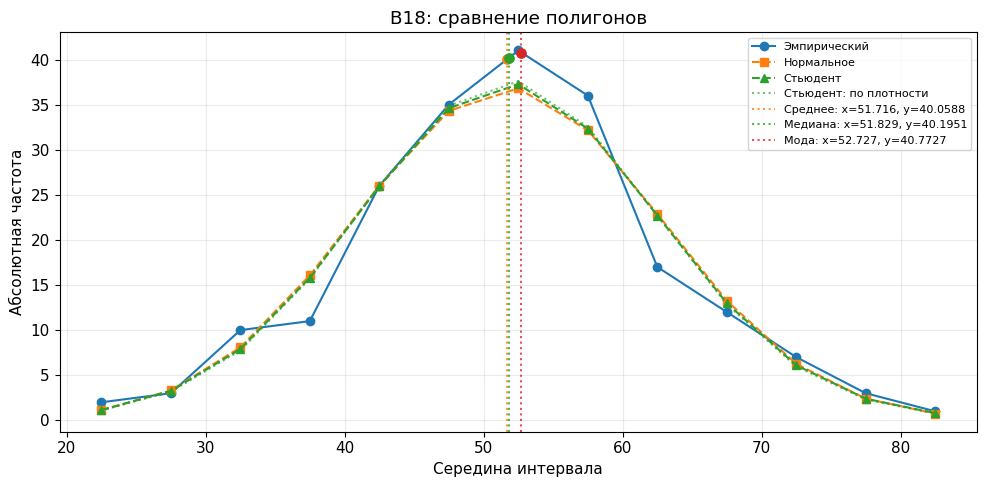

**Вывод.** Теоретические кривые близки. В интервале [50; 55) наблюдается 41 значений, нормальная модель даёт 36.81, Стьюдент — 37.26. По графику уверенно выбрать одну модель нельзя.

In [20]:
fig, ax = plt.subplots()
ax.plot(mid, fB, 'o-', label="Эмпирический")
ax.plot(mid, normal_cdf_freq, 's--', label="Нормальное")
ax.plot(mid, student_cdf_freq, '^--', label="Стьюдент")
ax.plot(mid, student_pdf_freq, ':', color='C2', alpha=.65, label="Стьюдент: по плотности")
ax.set(xlabel="Середина интервала", ylabel="Абсолютная частота", title="B18: сравнение полигонов")
mark_b(ax, "frequency")
ax.legend(fontsize=8); plt.show()
peak = int(np.argmax(fB))
note(f"**Вывод.** Теоретические кривые близки. В интервале {interval_labels[peak]} "
     f"наблюдается {fB[peak]} значений, нормальная модель даёт {normal_cdf_freq[peak]:.2f}, "
     f"Стьюдент — {student_cdf_freq[peak]:.2f}. По графику уверенно выбрать одну модель нельзя.")


### Доверительные интервалы для параметров B

Доверительный уровень $\gamma=0.95$ для каждого параметра отдельно.

#### 1. Нормальное распределение: точные интервалы

Используем исходные $n=204$ наблюдения. Вычисляем среднее $\bar x_{\rm исх}$ и исправленную дисперсию:
$$s^2=\frac1{n-1}\sum_{j=1}^n(B_j-\bar x_{\rm исх})^2
=\frac{n}{n-1}D_{n,\rm исх}.$$
Поправка $n/(n-1)$ устраняет смещение оценки дисперсии.

**Для математического ожидания:**
$$I_\mu=\left[\bar x_{\rm исх}-t_{0.975,203}\frac{s}{\sqrt n};\quad
\bar x_{\rm исх}+t_{0.975,203}\frac{s}{\sqrt n}\right].$$

**Для дисперсии:**
$$I_{\sigma^2}=\left[\frac{203s^2}{\chi^2_{0.975,203}};\quad
\frac{203s^2}{\chi^2_{0.025,203}}\right].$$
Для $\sigma$ берём квадратные корни границ. Квантили $t$ и $\chi^2$ вычисляем при 203 степенях свободы.

Интервалы точны при независимой нормальной выборке без учёта округления данных. Поэтому здесь используем исходные наблюдения, а не середины интервалов.


In [21]:
df = nB-1
mean_raw = float(B.mean())
s2 = float(B.var(ddof=1))
s_raw = np.sqrt(s2)
se_mean = s_raw/np.sqrt(nB)
tcrit = float(stats.t.ppf(.975, df))
chi_low, chi_high = stats.chi2.ppf([.025, .975], df)
ci_mu = mean_raw + np.array([-1, 1])*tcrit*se_mean
ci_sigma2 = np.array([df*s2/chi_high, df*s2/chi_low])
ci_sigma = np.sqrt(ci_sigma2)
note(f"Среднее {mean_raw:.4f}; s²={s2:.4f}; "
     f"t₀․₉₇₅={tcrit:.4f}; χ²₀․₀₂₅={chi_low:.4f}; χ²₀․₉₇₅={chi_high:.4f}.")
table(pd.DataFrame({"Параметр": ["μ", "σ²", "σ"], "Оценка": [mean_raw, s2, s_raw],
                    "Точный 95% интервал": [interval_text(ci_mu), interval_text(ci_sigma2), interval_text(ci_sigma)],
                    "Распределение статистики": ["t₂₀₃", "χ²₂₀₃", "Корни границ интервала σ²"]}))
note("**Вывод.** Получены точные нормальные интервалы по исходным данным. "
     "Отличие исходного среднего от сгруппированного связано с заменой значений серединами интервалов.")


Среднее 51.1618; s²=118.1067; t₀․₉₇₅=1.9717; χ²₀․₀₂₅=165.4348; χ²₀․₉₇₅=244.3511.

Параметр,Оценка,Точный 95% интервал,Распределение статистики
μ,51.1618,[49.6615; 52.6620],t₂₀₃
σ²,118.1067,[98.1197; 144.9251],χ²₂₀₃
σ,10.8677,[9.9055; 12.0385],Корни границ интервала σ²


**Вывод.** Получены точные нормальные интервалы по исходным данным. Отличие исходного среднего от сгруппированного связано с заменой значений серединами интервалов.

#### 2. Распределение Стьюдента: асимптотические интервалы

Для модели $X=a+bT_\nu$ используем оценки ММ по интервальному ряду. Стандартные ошибки получаем дельта-методом; вычисления оставлены в коде. Расчёт использует модельные моменты до восьмого порядка и требует $\nu>8$, что выполнено для полученной оценки.

**Прямой способ:**
$$I_a=[\hat a-zSE_a;\hat a+zSE_a],\qquad
I_b=[\hat b-zSE_b;\hat b+zSE_b]\cap(0;+\infty),$$
$$I_\nu=[\hat\nu-zSE_\nu;\hat\nu+zSE_\nu]\cap(4;+\infty),\qquad z=1.96.$$

**Функциональное преобразование.** Для положения $a$ интервал тот же. Для масштаба используем $\ln b$:
$$I_b^{(g)}=[\exp(\ln\hat b-zSE_{\ln b});\exp(\ln\hat b+zSE_{\ln b})].$$
Для числа степеней свободы используем связь $\nu=4+6/Es$. Построив интервал эксцесса $[L;U]$, получаем
$$I_\nu^{(g)}=\begin{cases}[4+6/U;4+6/L],&L>0,\\{}[4+6/U;+\infty),&L\le0<U.\end{cases}$$
Основным для $\nu$ считаем преобразованный интервал. Эти интервалы приближённые: используются асимптотические формулы и сгруппированные данные.


In [22]:
assert nu_mm > 8
centered_t = stats.t(df=nu_mm, scale=b_mm)
# Чётные центральные моменты вычисляем аналитически, без численного интегрирования.
cm = {0: 1.0, 1: 0.0, 3: 0.0, 5: 0.0, 7: 0.0}
for j in range(1, 5):
    odd_product = np.prod(np.arange(1, 2*j, 2, dtype=float))
    cm[2*j] = b_mm**(2*j)*nu_mm**j*odd_product/np.prod(nu_mm-2*np.arange(1, j+1))
v, q, e = dB, centralB[3], es
Sigma = np.array([[v, 0, 0], [0, cm[4]-v**2, cm[6]-v*cm[4]],
                  [0, cm[6]-v*cm[4], cm[8]-cm[4]**2]])
e_v, e_q = -2*q/v**3, 1/v**2
coef = -3/(2*(e+3)*(2*e+3))
J = np.array([[1, 0, 0], [0, 1/(2*v)+coef*e_v, coef*e_q], [0, e_v, e_q]])
se_t = np.sqrt(np.diag(J @ Sigma @ J.T)/nB)
ci_a_mm = a_mm + np.array([-1, 1])*z*se_t[0]
ci_b_mm = np.exp(np.log(b_mm) + np.array([-1, 1])*z*se_t[1])
ci_es = e + np.array([-1, 1])*z*se_t[2]
assert ci_es[1] > 0
ci_nu_mm = np.array([4+6/ci_es[1], np.inf if ci_es[0] <= 0 else 4+6/ci_es[0]])
se_b, se_nu = b_mm*se_t[1], 6/e**2*se_t[2]
ci_b_direct = np.maximum(0, b_mm + np.array([-1, 1])*z*se_b)
ci_nu_direct = np.maximum(4, nu_mm + np.array([-1, 1])*z*se_nu)
table(pd.DataFrame({"Величина": ["a", "b", "ν", "ln b", "Es"],
                    "Оценка": [a_mm, b_mm, nu_mm, np.log(b_mm), e],
                    "Стандартная ошибка": [se_t[0], se_b, se_nu, se_t[1], se_t[2]]}))
table(pd.DataFrame({"Параметр": ["a", "b", "ν"],
                    "Прямой 95% интервал": [interval_text(ci_a_mm), interval_text(ci_b_direct, 0), interval_text(ci_nu_direct, 4)],
                    "Преобразованный 95% интервал": [interval_text(ci_a_mm), interval_text(ci_b_mm), interval_text(ci_nu_mm)]}))
note(f"**Вывод.** Интервал эксцесса {interval_text(ci_es)} содержит 0. "
     f"Поэтому для ν получаем {interval_text(ci_nu_mm)}: нормальный предел не исключён. "
     "Для положения способы совпадают, для масштаба дают близкие границы.")


Величина,Оценка,Стандартная ошибка
a,51.7157,0.7653
b,10.7491,0.8254
ν,60.6548,215.4963
ln b,2.3748,0.0768
Es,0.1059,0.4028


Параметр,Прямой 95% интервал,Преобразованный 95% интервал
a,[50.2157; 53.2157],[50.2157; 53.2157]
b,[9.1313; 12.3669],[9.2471; 12.4950]
ν,(4.0000; 483.0197],[10.7007; +∞)


**Вывод.** Интервал эксцесса [-0.6836; 0.8954] содержит 0. Поэтому для ν получаем [10.7007; +∞): нормальный предел не исключён. Для положения способы совпадают, для масштаба дают близкие границы.

### Теоретические характеристики и сравнение

Нормальное распределение: среднее, медиана и мода равны $\mu$, дисперсия $\sigma^2$, $As=0$, $Es=0$.

Стьюдент $a+bT_\nu$ при $\nu>4$: среднее, медиана и мода равны $a$, дисперсия $b^2\nu/(\nu-2)$, $As=0$, $Es=6/(\nu-4)$; $m_3=0$, $m_4=3b^4\nu^2/[(\nu-2)(\nu-4)]$.

Для симметричной модели с центром $a$ и дисперсией $v$ начальные моменты равны: $\alpha_3=a^3+3av$, $\alpha_4=a^4+6a^2v+m_4$. Сравниваем с интервальными эмпирическими моментами B.

In [23]:
compareB = pd.DataFrame({"Интервальные": empirical_compare(cB),
    "Норма (по интервалам)": distribution_characteristics(normal,mu),
    "Стьюдент (ММ)": distribution_characteristics(student,a_mm)})
table(compareB)
def moments_row(mean,var,m3,m4):
    return {"α₃": mean**3+3*mean*var+m3,
            "α₄": mean**4+6*mean**2*var+4*mean*m3+m4,"m₃":m3,"m₄":m4}
rows_moments = {"Эмпирические": {key:cB[key] for key in ['α₃','α₄','m₃','m₄']},
                "Норма": moments_row(mu,sigma2,0,3*sigma2**2),
                "Стьюдент (ММ)": moments_row(a_mm,float(student.var()),0,float(centered_t.moment(4)))}
table(pd.DataFrame(rows_moments))
note("**Вывод.** Обе модели воспроизводят сгруппированные среднее и дисперсию. "
     "Стьюдент также воспроизводит эксцесс по построению ММ. "
     "Близость характеристик не заменяет проверку согласия.")


,Интервальные,Норма (по интервалам),Стьюдент (ММ)
Среднее,51.7157,51.7157,51.7157
Медиана,51.8293,51.7157,51.7157
Мода,52.727273,51.7157,51.7157
Дисперсия,119.4829,119.4829,119.4829
As,0.0036,0.0000,0.0000
Es,0.1059,0.0000,0.1059


,Эмпирические,Норма,Стьюдент (ММ)
α₃,156856.3113,156851.6534,156851.6534
α₄,9115670.1900,9113194.7345,9114706.6441
m₃,4.6579,0.0000,0.0000
m₄,44340.3935,42828.4839,44340.3935


**Вывод.** Обе модели воспроизводят сгруппированные среднее и дисперсию. Стьюдент также воспроизводит эксцесс по построению ММ. Близость характеристик не заменяет проверку согласия.

## Итоговые результаты

Ниже собраны эмпирические характеристики, выбранные модели и доверительные интервалы. Для B характеристики и оценки моделей основаны на интервальном ряде; точные нормальные интервалы — на исходных наблюдениях. Совпадение моментов с моделью по ММ не служит самостоятельной проверкой гипотез. Формальный критерий согласия не применялся.


In [24]:
summary = pd.DataFrame({
    "Пункт": ["Объём и обработка", "Среднее / медиана / мода", "Дисперсия / As / Es", "Гипотезы", "Параметры ММ", "95% интервалы", "Вывод"],
    "A": [f"n={nA}; дискретный ряд", f"{lam:.4f} / {cA['Медиана']:g} / {cA['Моды']}",
          f"{varA:.4f} / {cA['Асимметрия As']:.4f} / {cA['Эксцесс Es']:.4f}",
          "Пуассон; отрицательное биномиальное", f"λ={lam:.4f}; r={r_nb:.4f}; p={p_nb:.4f}",
          f"λ: {interval_text(ci_lam)}; r: {interval_text(ci_r, 0)}; p: {interval_text(ci_p, 0, 1)}",
          "Модели близки; параметр r определён неточно, пуассоновский предел не исключён"],
    "B": [f"n={nB}; {kB} интервалов, h={h:g}", f"{mean_group:.4f} / {median_group:.4f} / {mode_group:.4f}",
          f"{dB:.4f} / {cB['Асимметрия As']:.4f} / {cB['Эксцесс Es']:.4f}",
          "Нормальное; Стьюдента", f"μ={mu:.4f}; σ²={sigma2:.4f}; a={a_mm:.4f}; b={b_mm:.4f}; ν={nu_mm:.4f}",
          f"μ (точный): {interval_text(ci_mu)}; σ² (точный): {interval_text(ci_sigma2)}; ν: {interval_text(ci_nu_mm)}",
          "Модели близки; малый эксцесс и широкий интервал ν не позволяют исключить нормальный предел"]})
table(summary.set_index("Пункт"))


,A,B
Пункт,,
Объём и обработка,n=73; дискретный ряд,"n=204; 13 интервалов, h=5"
Среднее / медиана / мода,2.8493 / 3 / 3,51.7157 / 51.8293 / 52.7273
Дисперсия / As / Es,2.9773 / 0.5853 / 0.0562,119.4829 / 0.0036 / 0.1059
Гипотезы,Пуассон; отрицательное биномиальное,Нормальное; Стьюдента
Параметры ММ,λ=2.8493; r=63.4370; p=0.9570,μ=51.7157; σ²=119.4829; a=51.7157; b=10.7491; ν=60.6548
95% интервалы,λ: [2.4621; 3.2365]; r: [7.9392; +∞); p: [0.6696; 1.0000),μ (точный): [49.6615; 52.6620]; σ² (точный): [98.1197; 144.9251]; ν: [10.7007; +∞)
Вывод,"Модели близки; параметр r определён неточно, пуассоновский предел не исключён",Модели близки; малый эксцесс и широкий интервал ν не позволяют исключить нормальный предел


In [25]:
# Контроль согласованности рассчитанного отчёта.
assert A.size == 73 and B.size == 204
assert np.isclose(s2, B.var(ddof=1))
assert np.isclose(normal.mean(), mean_group)
assert np.isclose(normal.var(), dB)
assert all(ci[0] < ci[1] for ci in [ci_lam,ci_p,ci_r,ci_mu,ci_sigma2,ci_sigma,ci_a_mm,ci_b_mm,ci_nu_mm])

assert np.isclose(rawB[1]-rawB[0]**2, dB)
assert np.isclose(np.interp(median_group, edges, cum_group), .5)
assert np.isclose(cum_group[-1],1)

assert np.isclose(student.mean(), mean_group)
assert np.isclose(student.var(), dB)
assert np.isclose(float(student.stats(moments='k')), es)
assert np.allclose(cm[4], centralB[3])
assert np.all(np.linalg.eigvalsh(cov_uv) > 0)
assert np.all(np.linalg.eigvalsh(Sigma) > 0)
assert np.all(np.isfinite(se_t))
print("Контроль пройден: объёмы, частоты, моменты, параметры моделей, медиана кумуляты и границы интервалов согласованы.")


Контроль пройден: объёмы, частоты, моменты, параметры моделей, медиана кумуляты и границы интервалов согласованы.
